<a href="https://colab.research.google.com/github/swirita/salmonellosis-forecasting-analysis/blob/main/notebooks/03_salmonellosis_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Salmonellosis Forecasting

## Imports

In [33]:
%pip install -q pmdarima

In [34]:
# imports
import os
from datetime import date, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
import statsmodels.tsa.api as tsa
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_percentage_error

## Custom Functions

In [36]:
def plot_forecast(ts_train, ts_test, forecast_df, n_train_lags=None,
                  figsize=(10,4), title='Comparing Forecast vs. True Data'):
    ### PLot training data, and forecast (with upper/,lower ci)
    fig, ax = plt.subplots(figsize=figsize)
    # setting the number of train lags to plot if not specified
    if n_train_lags==None:
        n_train_lags = len(ts_train)

    # Plotting Training  and test data
    ts_train.iloc[-n_train_lags:].plot(ax=ax, label="train")
    ts_test.plot(label="test", ax=ax)
    # Plot forecast
    forecast_df['mean'].plot(ax=ax, color='green', label="forecast")
    # Add the shaded confidence interval
    ax.fill_between(forecast_df.index,
                    forecast_df['mean_ci_lower'],
                   forecast_df['mean_ci_upper'],
                   color='green', alpha=0.3,  lw=2)
    # set the title and add legend
    ax.set_title(title)
    ax.legend();

    return fig, ax

In [37]:
# Custom function for Ad Fuller Test
def get_adfuller_results(ts, alpha=.05, label='adfuller', **kwargs): #kwargs for adfuller()
    # Saving each output
    (test_stat, pval, nlags, nobs, crit_vals_d,
    icbest ) = tsa.adfuller(ts, **kwargs)
    # Converting output to a dictionary with the interpretation of p
    adfuller_results = {'Test Statistic': test_stat,
                        "# of Lags Used":nlags,
                       '# of Observations':nobs,
                        'p-value': round(pval,6),
                        'alpha': alpha,
                       'sig/stationary?': pval < alpha}
    return pd.DataFrame(adfuller_results, index =[label])

In [38]:
### NEW FUNCTION FOR COMBINED ACF/PACF WITH ANNOTATIONS
def plot_acf_pacf(ts, nlags=40, figsize=(10, 5),
                  annotate_sig=False, alpha=.05,
                 acf_kws={}, pacf_kws={},
                  annotate_seas=False, m = None,
                 seas_color='black'):

    fig, axes = plt.subplots(nrows=2, figsize=figsize)

    # Sig lags line style
    sig_vline_kwargs = dict( ls=':', lw=1, zorder=0, color='red')
    # ACF
    tsa.graphics.plot_acf(ts, ax=axes[0], lags=nlags, **acf_kws)

    ## Annotating sig acf lags
    if annotate_sig == True:
        sig_acf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='ACF')
        for lag in sig_acf_lags:
            axes[0].axvline(lag,label='sig', **sig_vline_kwargs )
    # PACF
    tsa.graphics.plot_pacf(ts,ax=axes[1], lags=nlags, **pacf_kws)

    ## Annotating sig pacf lags
    if annotate_sig == True:
        ## ANNOTATING SIG LAGS
        sig_pacf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='PACF')
        for lag in sig_pacf_lags:
            axes[1].axvline(lag, label='sig', **sig_vline_kwargs)

    ### ANNOTATE SEASONS
    if annotate_seas == True:
        # Ensure m was defined
        if m is None:
            raise Exception("Must define value of m if annotate_seas=True.")
        ## Calculate number of complete seasons to annotate
        n_seasons = nlags//m
        # Seasonal Lines style
        seas_vline_kwargs = dict( ls='--',lw=1, alpha=.7, color=seas_color, zorder=-1)

        ## for each season, add a line
        for i in range(1, n_seasons+1):
            axes[0].axvline(m*i, **seas_vline_kwargs, label="season")
            axes[1].axvline(m*i, **seas_vline_kwargs, label="season")
    fig.tight_layout()

    return fig


In [39]:
def regression_metrics_ts(ts_true, ts_pred, label="", verbose=True, output_dict=False,):
    # Get metrics
    mae = mean_absolute_error(ts_true, ts_pred)
    mse = mean_squared_error(ts_true, ts_pred)
    rmse = root_mean_squared_error(ts_true, ts_pred)
    r_squared = r2_score(ts_true, ts_pred)
    mae_perc = mean_absolute_percentage_error(ts_true, ts_pred) * 100

    if verbose == True:
        # Print Result with label
        header = "---" * 20
        print(header, f"Regression Metrics: {label}", header, sep="\n")
        print(f"- MAE = {mae:,.3f}")
        print(f"- MSE = {mse:,.3f}")
        print(f"- RMSE = {rmse:,.3f}")
        print(f"- R^2 = {r_squared:,.3f}")
        print(f"- MAPE = {mae_perc:,.2f}%")

    if output_dict == True:
        metrics = {
            "Label": label,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R^2": r_squared,
            "MAPE(%)": mae_perc,
        }
        return metrics

## Load and Prepare Data

In [40]:
# Connect Google Colab to Google Drive
from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:
# Project folders
project_folder = "/content/drive/MyDrive/Salmonellosis Forecasting and Analysis"
data_folder = os.path.join(project_folder, "data")

# Load the cleaned data created in the preparation notebook
cleaned_file_path = os.path.join(data_folder, "salmonellosis_weekly_cleaned.csv")
df = pd.read_csv(cleaned_file_path)

print(f"Data loaded: {df.shape[0]:,} rows and {df.shape[1]} columns")
display(df.head())


Data loaded: 17,079 rows and 10 columns


,Reporting Area,Current MMWR Year,MMWR WEEK,Label,Current week,Previous 52 week Max,Cumulative YTD Current MMWR Year,Cumulative YTD Previous MMWR Year,Season,Previous week cases
0,ALABAMA,2022,1,Salmonellosis (excluding Salmonella Typhi infe...,10,38.0,10,6.0,Winter,2.0
1,ALABAMA,2022,2,Salmonellosis (excluding Salmonella Typhi infe...,3,38.0,18,12.0,Winter,10.0
2,ALABAMA,2022,3,Salmonellosis (excluding Salmonella Typhi infe...,0,38.0,24,17.0,Winter,3.0
3,ALABAMA,2022,4,Salmonellosis (excluding Salmonella Typhi infe...,2,38.0,26,25.0,Winter,0.0
4,ALABAMA,2022,5,Salmonellosis (excluding Salmonella Typhi infe...,0,38.0,29,30.0,Winter,2.0


In [42]:
# Select the national weekly totals
national = df[
    df["Reporting Area"] == "US RESIDENTS"
].copy()

# Arrange the observations correctly
national = national.sort_values(
    ["Current MMWR Year", "MMWR WEEK"]
)

# Create one weekly date for every observation
national["Date"] = pd.date_range(
    start="2022-01-08",
    periods=len(national),
    freq="W-SAT"
)

# Use Date as the index
national = national.set_index("Date")

national.head()

,Reporting Area,Current MMWR Year,MMWR WEEK,Label,Current week,Previous 52 week Max,Cumulative YTD Current MMWR Year,Cumulative YTD Previous MMWR Year,Season,Previous week cases
Date,,,,,,,,,,
2022-01-08,US RESIDENTS,2022,1,Salmonellosis (excluding Salmonella Typhi infe...,96,1212.0,96,333.0,Winter,2.0
2022-01-15,US RESIDENTS,2022,2,Salmonellosis (excluding Salmonella Typhi infe...,77,1217.0,415,677.0,Winter,96.0
2022-01-22,US RESIDENTS,2022,3,Salmonellosis (excluding Salmonella Typhi infe...,24,1217.0,535,1016.0,Winter,77.0
2022-01-29,US RESIDENTS,2022,4,Salmonellosis (excluding Salmonella Typhi infe...,46,1217.0,663,1387.0,Winter,24.0
2022-02-05,US RESIDENTS,2022,5,Salmonellosis (excluding Salmonella Typhi infe...,65,1227.0,977,1699.0,Winter,46.0


In [43]:
# Keep only the column we want to forecast
weekly_cases = national[["Current week"]].copy()

# Give it a clearer name
weekly_cases = weekly_cases.rename(
    columns={"Current week": "Cases"}
)

# Make sure the values are numeric
weekly_cases["Cases"] = pd.to_numeric(
    weekly_cases["Cases"],
    errors="coerce"
)

weekly_cases.head()

,Cases
Date,
2022-01-08,96
2022-01-15,77
2022-01-22,24
2022-01-29,46
2022-02-05,65


In [44]:
print("First date:", weekly_cases.index.min())
print("Last date:", weekly_cases.index.max())
print("Number of weeks:", len(weekly_cases))
print("Missing case values:", weekly_cases["Cases"].isna().sum())

First date: 2022-01-08 00:00:00
Last date: 2026-09-05 00:00:00
Number of weeks: 244
Missing case values: 0


In [45]:
weekly_cases.index

DatetimeIndex(['2022-01-08', '2022-01-15', '2022-01-22', '2022-01-29',
               '2022-02-05', '2022-02-12', '2022-02-19', '2022-02-26',
               '2022-03-05', '2022-03-12',
               ...
               '2026-07-04', '2026-07-11', '2026-07-18', '2026-07-25',
               '2026-08-01', '2026-08-08', '2026-08-15', '2026-08-22',
               '2026-08-29', '2026-09-05'],
              dtype='datetime64[ns]', name='Date', length=244, freq=None)

In [46]:
pd.infer_freq(weekly_cases.index)

'W-SAT'

In [47]:
weekly_cases = weekly_cases.asfreq("W-SAT")
weekly_cases.isna().sum()

,0
Cases,0


In [48]:
weekly_cases.index

DatetimeIndex(['2022-01-08', '2022-01-15', '2022-01-22', '2022-01-29',
               '2022-02-05', '2022-02-12', '2022-02-19', '2022-02-26',
               '2022-03-05', '2022-03-12',
               ...
               '2026-07-04', '2026-07-11', '2026-07-18', '2026-07-25',
               '2026-08-01', '2026-08-08', '2026-08-15', '2026-08-22',
               '2026-08-29', '2026-09-05'],
              dtype='datetime64[ns]', name='Date', length=244, freq='W-SAT')

* note: during analysis , the data had a really high seasonality pattern in warm months of the summer , so a seasonal model is requeired. (m=52) which is equal to 12 months.

**REMEMBER THE DATA IS WEEKLY NOT MONTHLY SO WE USE 52.**

`SEASON_LENGTH= 52`
`TEST_SIZE= 52`
`FORECASTING_STEPS= 4`



## Forecast

### 1. Differencing, Stationarity, ACF, and PACF

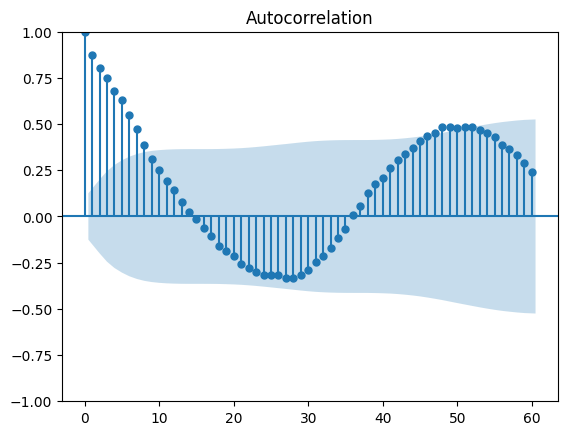

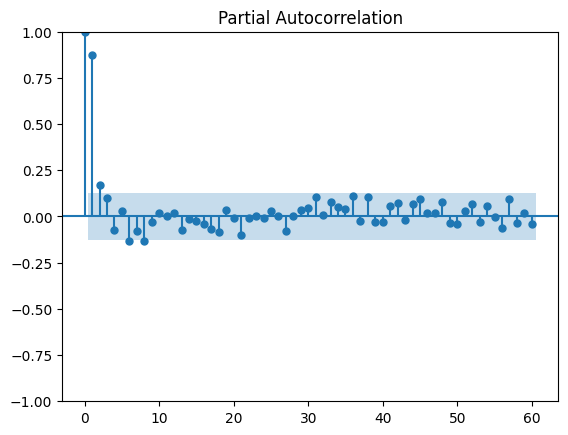

In [49]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plot_acf(weekly_cases["Cases"], lags=60)
plt.show()

plot_pacf(weekly_cases["Cases"], lags=60)
plt.show()

### 2. Train/Test Split and Manual SARIMA

In [50]:
TEST_SIZE = 52

train = weekly_cases.iloc[:-TEST_SIZE]
test = weekly_cases.iloc[-TEST_SIZE:]

print("Train:", train.index.min(), "to", train.index.max())
print("Test:", test.index.min(), "to", test.index.max())

Train: 2022-01-08 00:00:00 to 2025-09-06 00:00:00
Test: 2025-09-13 00:00:00 to 2026-09-05 00:00:00


In [52]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train["Cases"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 52)
)

model_fit = model.fit(disp=False)

forecast = model_fit.forecast(steps=52)

print(forecast)

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(


2025-09-13    729.711593
2025-09-20    722.571453
2025-09-27    625.384865
2025-10-04    687.819500
2025-10-11    625.249191
2025-10-18    557.538839
2025-10-25    625.572837
2025-11-01    499.764167
2025-11-08    493.594212
2025-11-15    543.843459
2025-11-22    453.738853
2025-11-29    543.834445
2025-12-06    519.120433
2025-12-13    436.461603
2025-12-20    376.683705
2025-12-27    240.319380
2026-01-03    394.978443
2026-01-10    399.387717
2026-01-17    366.278290
2026-01-24    398.363126
2026-01-31    359.211780
2026-02-07    397.372742
2026-02-14    370.917283
2026-02-21    382.644917
2026-02-28    396.458988
2026-03-07    418.989988
2026-03-14    428.180522
2026-03-21    432.330997
2026-03-28    468.762931
2026-04-04    454.868109
2026-04-11    424.862738
2026-04-18    482.399153
2026-04-25    488.596991
2026-05-02    522.169327
2026-05-09    535.330577
2026-05-16    535.063579
2026-05-23    519.111161
2026-05-30    548.068247
2026-06-06    584.722678
2026-06-13    614.745154


In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test["Cases"], forecast)
rmse = np.sqrt(mean_squared_error(test["Cases"], forecast))
mape = np.mean(np.abs((test["Cases"] - forecast) / test["Cases"])) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 119.7021427615996
RMSE: 165.55800763101755
MAPE: 42.98231432382516


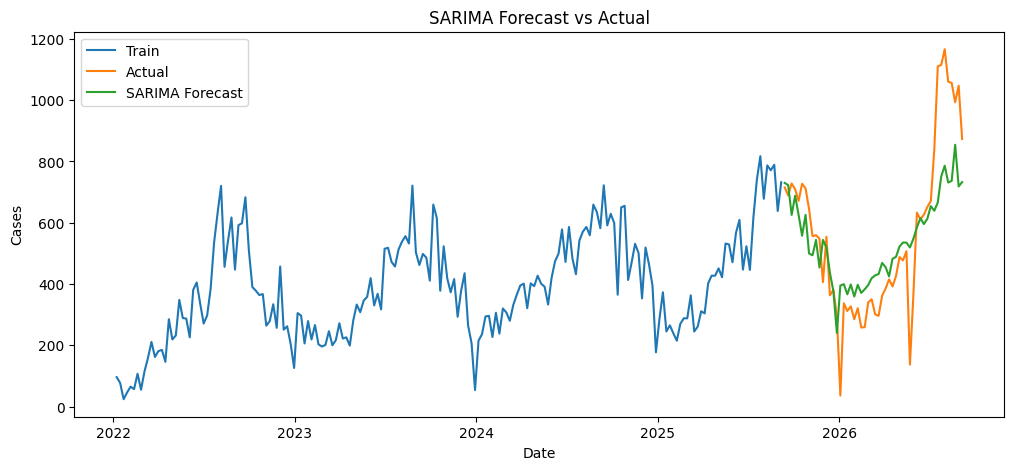

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(train.index, train["Cases"], label="Train")
plt.plot(test.index, test["Cases"], label="Actual")
plt.plot(test.index, forecast, label="SARIMA Forecast")

plt.title("SARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.legend()
plt.show()

### 3. Tune wuth `auto_arima`

In [55]:
from pmdarima import auto_arima

auto_model = auto_arima(
    train["Cases"],
    seasonal=True,
    m=52,
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore"
)

print(auto_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  192
Model:               SARIMAX(0, 1, 1)   Log Likelihood               -1120.998
Date:                Sun, 13 Sep 2026   AIC                           2245.995
Time:                        09:11:31   BIC                           2252.500
Sample:                    01-08-2022   HQIC                          2248.630
                         - 09-06-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4588      0.050     -9.109      0.000      -0.558      -0.360
sigma2      7324.6332    692.647     10.575      0.000    5967.070    8682.196
Ljung-Box (L1) (Q):                   0.03   Jarque-

In [56]:
auto_forecast = auto_model.predict(n_periods=52)

mae_auto = mean_absolute_error(test["Cases"], auto_forecast)
rmse_auto = np.sqrt(mean_squared_error(test["Cases"], auto_forecast))
mape_auto = np.mean(np.abs((test["Cases"] - auto_forecast) / test["Cases"])) * 100

print("Auto ARIMA MAE:", mae_auto)
print("Auto ARIMA RMSE:", rmse_auto)
print("Auto ARIMA MAPE:", mape_auto)

Auto ARIMA MAE: 266.9494141419242
Auto ARIMA RMSE: 313.00436921604154
Auto ARIMA MAPE: 102.58945607201856


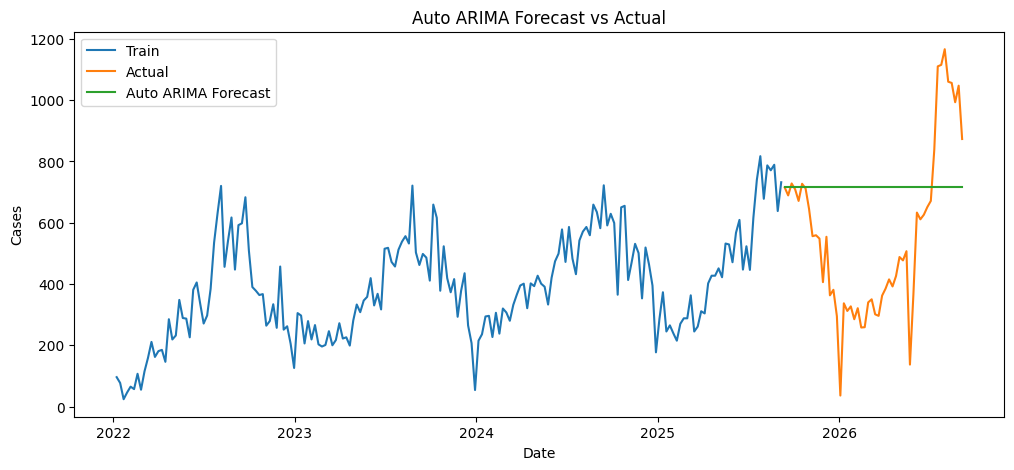

In [57]:
plt.figure(figsize=(12, 5))

plt.plot(train.index, train["Cases"], label="Train")
plt.plot(test.index, test["Cases"], label="Actual")
plt.plot(test.index, auto_forecast, label="Auto ARIMA Forecast")

plt.title("Auto ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.legend()
plt.show()

### 4. Select the Final Model and Forecast the Future

In [58]:
final_model = SARIMAX(
    weekly_cases["Cases"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 52)
)

final_model_fit = final_model.fit(disp=False)

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  start_params = self.start_params


## Final Evaluation

In [61]:
future_forecast = final_model_fit.forecast(steps=26)

print(future_forecast)

2026-09-12    989.216387
2026-09-19    963.036872
2026-09-26    957.700993
2026-10-03    971.496210
2026-10-10    878.124080
2026-10-17    940.229235
2026-10-24    962.038880
2026-10-31    832.370076
2026-11-07    807.097122
2026-11-14    840.799681
2026-11-21    795.957223
2026-11-28    735.376779
2026-12-05    828.367780
2026-12-12    706.438941
2026-12-19    675.849509
2026-12-26    540.233145
2027-01-02    521.593213
2027-01-09    665.684276
2027-01-16    616.519558
2027-01-23    636.945117
2027-01-30    597.530469
2027-02-06    621.511272
2027-02-13    598.726411
2027-02-20    613.150114
2027-02-27    647.382113
2027-03-06    675.552427
Freq: W-SAT, Name: predicted_mean, dtype: float64


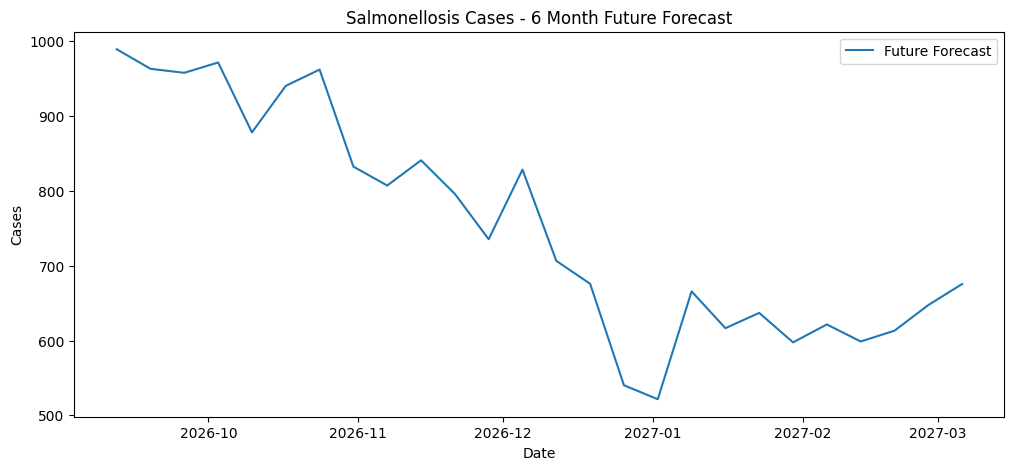

In [60]:
plt.figure(figsize=(12, 5))

plt.plot(future_forecast.index, future_forecast, label="Future Forecast")

plt.title("Salmonellosis Cases - 6 Month Future Forecast")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.legend()
plt.show()